In [2]:
import jax
import jax.numpy as jnp
import immrax as irx
print(jax.devices())

[CudaDevice(id=0)]


In [3]:

from immutabledict import immutabledict
from faulty_nonholonomic_car import FaultyNonHolonomicCar
# Define initial state bounds (intervals) using icentpert
from typing import Union


#

car_system = FaultyNonHolonomicCar()

faulty_car_embedding_system = irx.natemb(car_system)
print(faulty_car_embedding_system)
# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.02, .02, .02, .02])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([1, 1])  # Fixed control input
u_interval = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.
w_interval = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
w_interval_no_fault = irx.icentpert(jnp.zeros(1), jnp.zeros(1))
p_interval = irx.icentpert(jnp.array([0]), jnp.array([.0]))
# Propagate the interval for 1 second
t_end = 1.0  # 1 second
def u_map_in_func(t, x):
    return u_fixed
def w_map_in_func(t, x):
    return w_fixed
def p_map_in_func(t, x):
    return p_interval
# faulty_car_embedding_system.f(0, x0_interval, u_fixed, w_fixed, p_interval)
x_trajectory_actuator_fault = faulty_car_embedding_system.compute_trajectory(0., t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))
 

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_trajectory_actuator_fault)

Initial interval of states: [[(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]]
Final interval of states after 1 second: <immrax.system.Trajectory object at 0x7077b40e4f90>


In [4]:
print(jax.devices('gpu'))

[CudaDevice(id=0)]


In [5]:
def propagate_interval(
        embedding_system: irx.System, 
        x0_interval: irx.Interval, 
        u_interval: Union[jnp.ndarray, irx.Interval], 
        w_interval: Union[jnp.ndarray, irx.Interval], 
        p_interval: Union[jnp.ndarray, irx.Interval], 
        t_end: float
    ) -> irx.Interval:
    def u_map_in_func(t, x):
        return u_interval
    def w_map_in_func(t, x):
        return w_interval
    def p_map_in_func(t, x):
        return p_interval
    x_traj = embedding_system.compute_trajectory(0.0, t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))
    x_emb = x_traj.ys[-1]
    x_ivl = irx.Interval(lower=x_emb[:4], upper=x_emb[4:])
    return x_ivl

In [6]:
x_emb_actuator_fault = x_trajectory_actuator_fault.ys[-1]
x_interval_actuator_fault = irx.Interval(lower=x_emb_actuator_fault[:4], upper=x_emb_actuator_fault[4:])

Generate Interval WITHOUT Actuator Fault

In [7]:
normal_car_system = FaultyNonHolonomicCar()
normal_car_embedding_system = irx.natemb(normal_car_system)
# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.02, .02, .02, .02])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([0.2, 0.2])  # Fixed control input
w_fixed = jnp.array([jnp.pi/4.0])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.

# Propagate the interval for 1 second
t_end = 1.0  # 1 second
p_no_disturbance = irx.icentpert(jnp.array([.25]), jnp.array([.25]))

x_trajectory_no_fault = normal_car_embedding_system.compute_trajectory(0, t_end, irx.i2ut(x0_interval), (u_map_in_func, w_map_in_func, p_map_in_func))

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_trajectory_no_fault)

Initial interval of states: [[(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]
 [(-0.02, 0.02)]]
Final interval of states after 1 second: <immrax.system.Trajectory object at 0x7077b42c2e50>


In [8]:
x_emb_no_fault = x_trajectory_no_fault.ys[-1]
x_interval_no_fault = irx.Interval(lower=x_emb_no_fault[:4], upper=x_emb_no_fault[4:])

Add an observation fault

In [9]:
offset = jnp.array([0.2, 0.2, 0., 0.2])
x_interval_observation_fault = x_interval_no_fault + offset

Plot observation of system

In [10]:
import matplotlib.pyplot as plt
def plot_observation_boxes(x_interval_actuator_fault, x_interval_no_fault, x_interval_observation_fault, starting_observation=x0_interval, new_observation_interval=None, new_observation=None):
    # Extract the x and y positions from the final interval
    x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
    y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
    x_pos_interval_no_fault = x_interval_no_fault[0]
    y_pos_interval_no_fault = x_interval_no_fault[1]
    x_pos_interval_observation_fault = x_interval_observation_fault[0]
    y_pos_interval_observation_fault = x_interval_observation_fault[1]

    # Plot the interval of x and y positions
    plt.figure(figsize=(8, 6))
    plt.fill_between(
        [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
        [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
        [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
        alpha=0.5,
        color="blue",
        label="Observation Set (x, y) - Actuator Fault"
    )
    plt.fill_between(
        [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
        [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
        [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
        alpha=0.5,
        color="green",
        label="Observation Set (x, y) - No Fault"
    )
    plt.fill_between(
        [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
        [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
        [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
        alpha=0.5,
        color="yellow",
        label="Observation Set (x, y) - Observer Fault"
    )
    plt.fill_between(
        [starting_observation.lower[0], starting_observation.upper[0]],
        [starting_observation.lower[1], starting_observation.lower[1]],
        [starting_observation.upper[1], starting_observation.upper[1]],
        color="red",
        label="Starting Observation"
    )
    if new_observation_interval:
        plt.fill_between(
            [new_observation_interval.lower[0], new_observation_interval.upper[0]],
            [new_observation_interval.lower[1], new_observation_interval.lower[1]],
            [new_observation_interval.upper[1], new_observation_interval.upper[1]],
            color="cyan",
            label="Interval Containing New Observation"
        )    
    try:
        plt.plot(new_observation[0], new_observation[1], "mo", label="Actual New Observation")
    except:
        pass
    plt.xlabel("x position")
    plt.ylabel("y position")
    plt.title("Observation of x and y Positions after 1 Second")
    plt.legend()
    plt.grid()
    plt.show()

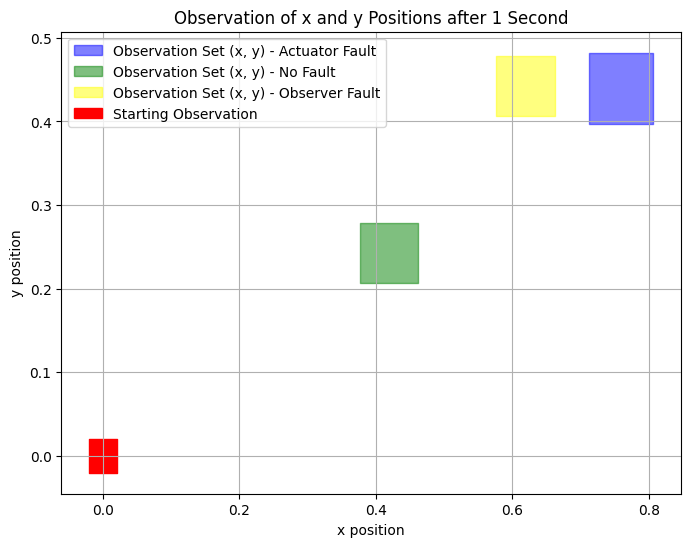

In [11]:
import matplotlib.pyplot as plt
# Extract the x and y positions from the final interval
x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
x_pos_interval_no_fault = x_interval_no_fault[0]
y_pos_interval_no_fault = x_interval_no_fault[1]
x_pos_interval_observation_fault = x_interval_observation_fault[0]
y_pos_interval_observation_fault = x_interval_observation_fault[1]

# Plot the interval of x and y positions
plt.figure(figsize=(8, 6))
plt.fill_between(
    [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
    [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
    [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
    alpha=0.5,
    color="blue",
    label="Observation Set (x, y) - Actuator Fault"
)
plt.fill_between(
    [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
    [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
    [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
    alpha=0.5,
    color="green",
    label="Observation Set (x, y) - No Fault"
)
plt.fill_between(
    [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
    [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
    [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
    alpha=0.5,
    color="yellow",
    label="Observation Set (x, y) - Observer Fault"
)
plt.fill_between(
    [x0_interval.lower[0], x0_interval.upper[0]],
    [x0_interval.lower[1], x0_interval.lower[1]],
    [x0_interval.upper[1], x0_interval.upper[1]],
    color="red",
    label="Starting Observation"
)
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Observation of x and y Positions after 1 Second")
plt.legend()
plt.grid()
plt.show()

In [12]:
def overlap_size(interval1, interval2):
    # Compute the intersection lower and upper bounds
    intersection_lower = jnp.maximum(interval1.lower, interval2.lower)
    intersection_upper = jnp.minimum(interval1.upper, interval2.upper)
    print(intersection_lower)
    print(intersection_upper)
    # Calculate the size of the intersection
    intersection_size = jnp.absolute(jnp.prod(intersection_upper - intersection_lower))
    
    return intersection_size

In [13]:
def actuator_observer_intervals_given_u(x0_interval, u_fixed):
    u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
    x_interval_no_fault = propagate_interval(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
    x_interval_observation_fault = x_interval_no_fault + offset
    return x_interval_actuator_fault, x_interval_observation_fault



In [14]:
def actuator_observer_fault_overlap(x0_interval, u_fixed):
    u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
    x_interval_no_fault = propagate_interval(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
    x_interval_observation_fault = x_interval_no_fault + offset
    return overlap_size(x_interval_actuator_fault, x_interval_observation_fault)

In [15]:
# af_1, of_1 = 

In [16]:
import jax
from jax import value_and_grad
from jax.scipy.optimize import minimize
def minimize_control_input(x_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt):
    # Define the objective function
    def objective(u):
        return actuator_observer_fault_overlap(x_interval, u)

    # Initial guess for control input
    u_init = jnp.zeros(2)  # Example: 2D control input

    # Minimize the objective function
    result = minimize(objective, u_init, method="BFGS")
    return result.x

def is_outside(interval1, interval2):
    # Check if interval1 is fully outside interval2
    return jnp.all(interval1.upper < interval2.lower) or jnp.all(interval1.lower > interval2.upper)

from jax import random

def get_noisy_measurement(x, delta, key):
    """
    Returns a random interval that is δ-wide and contains the true output.

    Args:
        x_interval (array): The true output interval (lower and upper bounds).
        delta (float): The noise level (width of the interval).
        key (jax.random.PRNGKey): Random key for JAX's random number generator.

    Returns:
        Interval: A noisy interval containing the true output.
    """


    # Generate random noise for lower and upper bounds
    key, subkey = random.split(key)
    noise_lower = random.uniform(subkey, shape=x.shape, minval=-delta, maxval=0)  # Noise for lower bound
    key, subkey = random.split(key)
    noise_upper = random.uniform(subkey, shape=x.shape, minval=0, maxval=delta)  # Noise for upper bound

    # Compute noisy bounds
    noisy_lower = x + noise_lower
    noisy_upper = x + noise_upper


    # Return the noisy interval
    return irx.Interval(lower=noisy_lower, upper=noisy_upper)


In [17]:
import jax
def armijo_step_size(u, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, grad_u, alpha_init=1.0, c=0.5, tau=0.5, max_iter=100):
    """
    Perform backtracking line search to find a step size that satisfies the Armijo condition.

    Args:
        u: Current control input.
        grad_u: Gradient of the objective function at u.
        alpha_init: Initial step size.
        c: Constant for the Armijo condition (typically 0.5).
        tau: Reduction factor for the step size (typically 0.5).
        max_iter: Maximum number of iterations for the line search.

    Returns:
        alpha: Step size that satisfies the Armijo condition.
    """
    alpha = alpha_init
    f_u = actuator_observer_fault_overlap(x0_interval,u, )
    grad_norm_sq = jnp.sum(grad_u**2)  # Squared norm of the gradient

    for _ in range(max_iter):
        # Compute the candidate update
        u_new = u - alpha * grad_u
        f_u_new = actuator_observer_fault_overlap(x0_interval, u_new)

        # Check the Armijo condition
        if f_u_new <= f_u - c * alpha * grad_norm_sq:
            return alpha  # Step size satisfies the condition

        # Reduce the step size
        alpha = tau * alpha

    return alpha  
# Gradient descent with Armijo rule
def gradient_descent_armijo(u_init, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, alpha_init=10, c=0.5, tau=0.5, max_iter=5, tol=1e-3):
    """
    Perform gradient descent with Armijo rule to minimize the objective function.

    Args:
        u_init: Initial guess for the control input.
        alpha_init: Initial step size for the Armijo rule.
        c: Constant for the Armijo condition.
        tau: Reduction factor for the step size.
        max_iter: Maximum number of iterations.
        tol: Tolerance for convergence.

    Returns:
        u_opt: Optimal control input.
    """
    def actuator_observer_intervals_given_x(u_fixed):
        u_interval_if = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
        w_interval_if = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
        x_interval_no_fault = propagate_interval(irx.natemb(normal_car_system), x0_interval, u_interval_if, w_interval_no_fault, p_no_disturbance, t_end)
        x_interval_actuator_fault = propagate_interval(irx.natemb(car_system), x0_interval=x0_interval, u_interval=u_interval_if, w_interval=w_interval_if, p_interval=p_interval, t_end=t_end)
        x_interval_observation_fault = x_interval_no_fault + offset
        # print(f"Intervals: actuator fault: {x_interval_actuator_fault}, observer fault: {x_interval_observation_fault}")
        return x_interval_actuator_fault, x_interval_observation_fault

    def actuator_observer_fault_overlap_given_x(u_fixed):
        x_interval_actuator_fault, x_interval_observation_fault = actuator_observer_intervals_given_x(u_fixed)
        return overlap_size(x_interval_actuator_fault, x_interval_observation_fault)
    u = u_init
    
    aofo_grad = jax.jacrev(actuator_observer_fault_overlap_given_x)
    for i in range(max_iter):
        # Compute the gradient
        grad_u = aofo_grad(u)
        # print(grad_u)
        # print(jnp.linalg.norm(grad_u))
        # Check for convergence
        print(f"At iteration {i}, Gradient is {grad_u} and overlap area is {actuator_observer_fault_overlap_given_x(u)}")
        if jnp.linalg.norm(grad_u) < tol or actuator_observer_fault_overlap_given_x(u) < tol:
            print(f"Converged after {i} iterations.")
            break

        # Compute step size using Armijo rule
        alpha = armijo_step_size(u, x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, grad_u, alpha_init, c, tau)

        # Update the control input
        u = u - alpha * grad_u
    else:
        print(f"Reached maximum iterations ({max_iter}).")

    return u

In [25]:
from jax import random
rng_key = random.PRNGKey(42)
real_car_system = FaultyNonHolonomicCar()
def fault_detection(x0_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt, max_iter=100):
    fault_cases = ["actuator", "observer"]  # Initial fault cases
    x_interval = x0_interval
    x_actual = jnp.zeros(4)
    t = 0
    for i in range(max_iter):
        # Compute optimal control input
        u_opt = gradient_descent_armijo(jnp.zeros(2),x_interval, w_interval, p_no_disturbance, p_actuator_fault, observer_offset, dt)
        # print(u_opt)
        previous_observation_interval = x_interval
        previous_state = x_actual
        # Propagate system with optimal control input
        x_interval_no_fault = propagate_interval(normal_car_embedding_system, x_interval, u_opt, w_interval_no_fault, p_no_disturbance, dt)
        x_interval_actuator_fault = propagate_interval(faulty_car_embedding_system, x_interval, u_opt, w_interval, p_actuator_fault, dt)
        x_interval_observer_fault = x_interval_no_fault + observer_offset
        def u_map_in_func(t, x):
            return u_opt
        def w_map_in_func(t, x):
            return jnp.array([0, 0])
        def p_map_in_func(t, x):
            return jnp.array([0])
        real_traj = real_car_system.compute_trajectory(0.0, t + dt, previous_state, (u_map_in_func, w_map_in_func, p_map_in_func))
        x_actual = real_traj.ys[-1]
        overlap_size_this_i = overlap_size(x_interval_actuator_fault[0:2], x_interval_observer_fault[0:2])
        # Obtain noisy measurement (δ-wide interval)
        print(f"At time step {i}, overlap size is {overlap_size_this_i}")
        measurement_interval = get_noisy_measurement(x_actual + jnp.array([.2, .2, 0 , .2]), delta=0.02, key=rng_key)

        # Check if measurement is outside fault case intervals
        if is_outside(measurement_interval[0:2], x_interval_actuator_fault[0:2]) and "actuator" in fault_cases:
            fault_cases.remove("actuator")
        if is_outside(measurement_interval[0:2], x_interval_observer_fault[0:2]) and "observer" in fault_cases:
            fault_cases.remove("observer")

        t += dt

        print(f"Time: {t}s")
        print(f"Applied control effort: {u_opt}")
        plot_observation_boxes(
            x_interval_no_fault=x_interval_no_fault, 
            x_interval_actuator_fault=x_interval_actuator_fault, 
            x_interval_observation_fault=x_interval_observer_fault,
            starting_observation=previous_observation_interval,
            new_observation_interval=measurement_interval,
            new_observation=x_actual[0:2]
        )

        # Update state interval
        x_interval = measurement_interval

        # If only one fault case remains, return it
        if len(fault_cases) == 1:
            return fault_cases[0]
        
        if len(fault_cases) == 0:
            return "None"

    return "unknown"  # If max_iter is reached without conclusion

In [30]:
import jax
import jax.numpy as jnp
from jax import grad, jit, random
from functools import partial

def observation_interval_size(x_interval):
    """Compute the size of the observation interval (sum of interval widths)."""
    # x_interval is assumed to be a 2D array where each row is [lower, upper] for a state variable.
    widths = x_interval.upper - x_interval.lower
    return jnp.sum(widths)

def propagate_with_feedback(x_interval, K, dt, faulty_system, p_actuator_fault):
    """Propagate the state interval under feedback control u = Kx."""
    # Assuming x_interval is a 4D state (lower and upper bounds for each state variable)
    # and K is a 2x4 matrix (since u is 2D and x is 4D).
    # For simplicity, we'll approximate the propagation of the interval under u = Kx.
    # This is a placeholder; you may need a more rigorous interval propagation method.
    x_center = (x_interval.lower + x_interval.upper) / 2
    u = K @ x_center  # Feedback control
    x_interval_propagated = propagate_interval(
        faulty_system, x_interval, u, w_interval, p_actuator_fault, dt
    )
    return x_interval_propagated

def loss(K, x_interval, dt, faulty_system, p_actuator_fault):
    """Loss function: size of the propagated observation interval."""
    x_propagated = propagate_with_feedback(x_interval, K, dt, faulty_system, p_actuator_fault)
    return observation_interval_size(x_propagated[0:2])  # Only consider position states

@partial(jit, static_argnums=(3,))
def optimize_K(x_interval, dt, faulty_system, p_actuator_fault, learning_rate=0.01, max_iter=100):
    """Optimize K to minimize observation interval size."""
    # Initialize K as a zero matrix (shape: 2x4, since u is 2D and x is 4D)
    K = jnp.zeros((2, 4))
    loss_grad = grad(loss)  # Gradient of the loss w.r.t. K

    for i in range(max_iter):
        grad_K = loss_grad(K, x_interval, dt, faulty_system, p_actuator_fault)
        K = K - learning_rate * grad_K  # Gradient descent update
        current_loss = loss(K, x_interval, dt, faulty_system, p_actuator_fault)
        print(f"Iteration {i}, Loss: {current_loss}, K: {K}")

    return K



In [ ]:
K_opt = optimize_K(
    x_interval=x0_interval,
    dt=1,
    faulty_system=faulty_car_embedding_system,  # Your faulty system dynamics
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])),
    learning_rate=0.01,
    max_iter=5
)

In [19]:
import profile
import re

In [26]:
fault_detection(
    x0_interval=x0_interval, 
    w_interval=w_interval, 
    p_no_disturbance=irx.icentpert(jnp.zeros(1), jnp.zeros(1)),
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])),
    observer_offset=jnp.array([.2, .2, .2, .2,]),
    dt=1,
    max_iter=10,
    )

KeyboardInterrupt: 

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x70785bb188d0>>
Traceback (most recent call last):
  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/profile.py", line 208, in trace_dispatch_i
    if self.dispatch[event](self, frame, t):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/profile.py", line 261, in trace_dispatch_call
    assert rframe.f_back is frame.f_back, ("Bad call", rfn,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: ('Bad call', ('/home/user/anaconda3/envs/brendan-immrax/lib/python3.11/site-packages/jax/_src/interpreters/partial_eval.py', 2566, 'inline_jaxpr_into_trace'), <frame at 0x70737669e700, file '/home/user/anaconda3/envs/br

Traced<ShapedArray(float32[4])>with<JVPTrace> with
  primal = Array([0.2923992 , 0.17960009, 0.76539874, 0.76539874], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7073b78caae0>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>), out_tracer_refs=[<weakref at 0x70739be275b0; to 'JaxprTracer' at 0x70739be27510>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None, None, None, None), 'out_layouts': (None,), 'donated_invars':

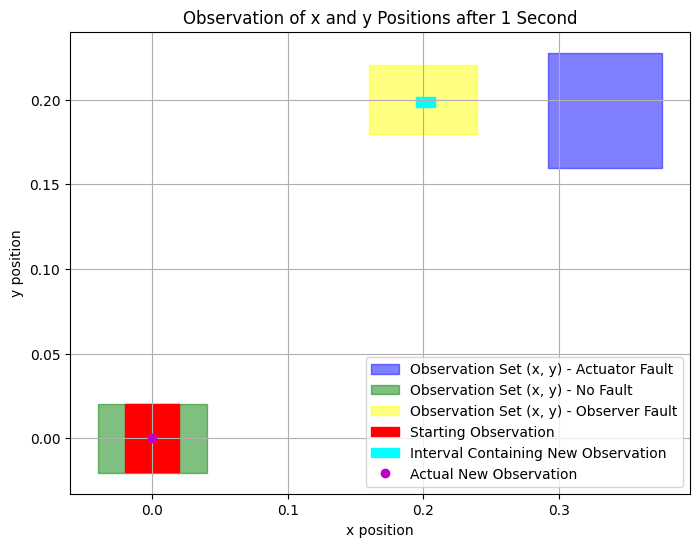

Traced<ShapedArray(float32[4])>with<JVPTrace> with
  primal = Array([0.6929709 , 0.4498155 , 0.76903266, 0.97065157], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x70773c3b5970>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>, Traced<ShapedArray(float32[4]):JaxprTrace>), out_tracer_refs=[<weakref at 0x7075e3c66250; to 'JaxprTracer' at 0x707399c9fbf0>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (UnspecifiedValue,), 'in_layouts': (None, None, None, None), 'out_layouts': (None,), 'donated_invars':

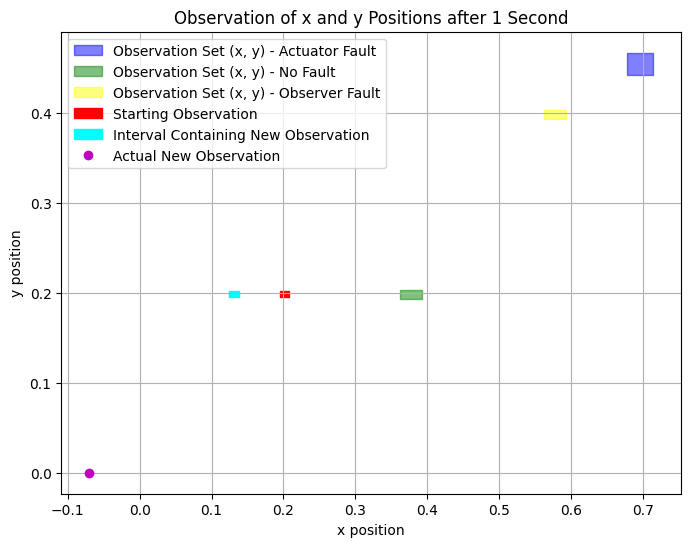

         27832 function calls (27419 primitive calls) in 97.217 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   97.196   97.196 1235443971.py:35(gradient_descent_armijo)
        1    0.000    0.000   97.193   97.193 1235443971.py:50(actuator_observer_intervals_given_x)
        1    0.000    0.000   97.193   97.193 1235443971.py:59(actuator_observer_fault_overlap_given_x)
        1    0.000    0.000   97.146   97.146 2631417610.py:1(propagate_interval)
        1    0.000    0.000    0.000    0.000 2631417610.py:11(w_map_in_func)
        1    0.000    0.000    0.000    0.000 2631417610.py:13(p_map_in_func)
        1    0.000    0.000    0.000    0.000 2631417610.py:9(u_map_in_func)
        1    0.000    0.000   97.198   97.198 643624110.py:4(fault_detection)
        6    0.000    0.000    0.000    0.000 :0(__build_class__)
       22    0.000    0.000    0.000    0.000 :0(__contains__)
        9  

In [27]:
profile.run("fault_detection( \
    x0_interval=x0_interval,  \
    w_interval=w_interval,  \
    p_no_disturbance=irx.icentpert(jnp.zeros(1), jnp.zeros(1)), \
    p_actuator_fault=irx.icentpert(jnp.array([.5]), jnp.array([0])), \
    observer_offset=jnp.array([.2, .2, .2, .2,]), \
    dt=1,\
    max_iter=10,\
    )")

In [ ]:
from jax import grad, jacfwd, jacrev
# overlap_size(x_interval_actuator_fault[0:2], x_interval_observation_fault[0:2])
# overlap_size_grad = grad(actuator_observer_fault_overlap)
overlap_size_jacobian = grad(actuator_observer_fault_overlap)
# print("Overlap size Gradient", overlap_size_grad(jnp.array([.1, .1])))
# propagate_interval_jacobian = jacrev(propagate_interval)
# print("Propagate interval Reverse Jacobian", propagate_interval_jacobian(normal_car_embedding_system, x0_interval, u_fixed, w_fixed, p_interval, 1.0))
print("Overlap size Forward Jacobian", overlap_size_jacobian(x0_interval, jnp.array([.1, .1])))

Traced<ConcreteArray([0.15918237 0.08502489 0.685398   0.78539807], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.15918237, 0.08502489, 0.685398  , 0.78539807], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7fda11a5c630>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1. 0. 1. 1.], dtype=float32):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0. 1. 0. 0.], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x7fd98d5d1760; to 'JaxprTracer' at 0x7fd98d5d1670>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] = mul b d
    g:f32[4] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue

In [ ]:
# Gradient descent parameters
learning_rate = 10  # Step size for gradient descent
max_iterations = 10  # Maximum number of iterations
tolerance = 1e-6  # Convergence tolerance

# Initial control input (replace with your initial guess)
u = jnp.array([0.0, 0.0])

# Gradient descent loop
for i in range(max_iterations):
    # Compute the overlap size and its gradient
    intersection_size = actuator_observer_fault_overlap(u)
    gradient = overlap_size_jacobian(u)
    
    # Check for convergence
    if jnp.abs(intersection_size) < tolerance:
        print(f"Converged at iteration {i} with overlap size {intersection_size}")
        break
    
    # Update the control input using gradient descent
    u = u - learning_rate * gradient
    
    # Print progress
 
    print(f"Iteration {i}: overlap size = {intersection_size}, u = {u}")

[0.3273081  0.22949149 0.685398   0.885398  ]
[0.54513395 0.3717006  0.88539785 0.88539785]
Traced<ConcreteArray([0.3273081  0.22949149 0.685398   0.885398  ], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.3273081 , 0.22949149, 0.685398  , 0.885398  ], dtype=float32)
  tangent = Traced<ShapedArray(float32[4])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[4]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x739219f84040>, in_tracers=(Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ShapedArray(float32[4]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0.  0.  0.5 0. ], dtype=float32):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1.  1.  0.5 1. ], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x739134bc2610; to 'JaxprTracer' at 0x739134bc1a80>], out_avals=[ShapedArray(float32[4])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[4] b:f32[4] c:f32[4] d:f32[4]. let
    e:f32[4] = mul a c
    f:f32[4] =

In [ ]:
print("Optimal u: ", u)

Optimal u:  [0. 0.]


In [ ]:
optimal_u = u
optimal_u_interval = irx.icentpert(optimal_u, jnp.zeros_like(optimal_u))
x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, optimal_u_interval, w_interval, p_no_disturbance, t_end)
x_interval_actuator_fault = propagate_interval(car_system, x0_interval=x0_interval, u_interval=optimal_u_interval, w_interval=w_interval, p_interval=p_interval, t_end=t_end)
x_interval_observation_fault = x_interval_no_fault + offset

TypeError: Unexpected input type for array: <class 'immrax.inclusion.interval.Interval'>

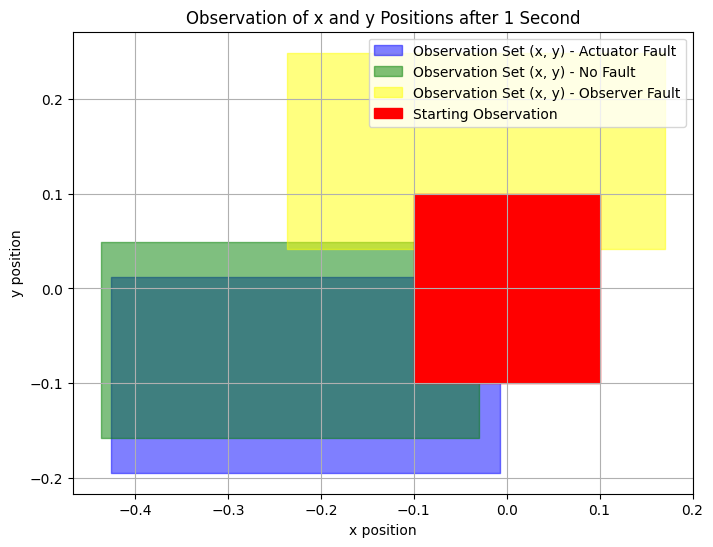

In [ ]:
plot_observation_boxes(x_interval_no_fault=x_interval_no_fault, x_interval_actuator_fault=x_interval_actuator_fault, x_interval_observation_fault=x_interval_observation_fault)